# XResNet1d-101 on PTB-XL

Multi-label ECG classification using a 1-D XResNet-101.

## Sections
1. Setup & Data Loading
2. Model Construction
3. Training
4. Evaluation


## 0. Install dependencies

In [1]:
import sys, os
# Add project root to path so local packages are importable
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import sys
print(sys.executable)


c:\Users\inaki\anaconda3\envs\ptbxl\python.exe


## 1. Load PTB-XL data

In [2]:
import sys
sys.path.append(r"C:/Users/inaki/Desktop/TFG/Code/ptbxl_project")

from utils import load_ptbxl, build_dataloaders

PATH = r"C:/Users/inaki/Desktop/TFG/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"

# PATH = "/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"
SAMPLING_RATE = 100

X_train, X_val, X_test, y_train, y_val, y_test, classes = load_ptbxl(PATH, SAMPLING_RATE)

print("Classes         :", classes)
print("X_train shape   :", X_train.shape)
print("X_val   shape   :", X_val.shape)
print("X_test  shape   :", X_test.shape)


Classes         : ['CD', 'HYP', 'MI', 'NORM', 'STTC']
X_train shape   : (17418, 1000, 12)
X_val   shape   : (2183, 1000, 12)
X_test  shape   : (2198, 1000, 12)


In [3]:
train_dl, val_dl, test_dl = build_dataloaders(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    batch_size=32,
)
print("Dataloaders ready.")


Dataloaders ready.


## 2. Build the XResNet1d-101 model

In [4]:
import torch
from models import build_xresnet1d101

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

model = build_xresnet1d101(
    num_classes=len(classes),
    input_channels=12,
    device=DEVICE,
)
print(model)


Device: cuda
XResNet1d(
  (0): ConvLayer(
    (0): Conv1d(12, 32, kernel_size=(5,), stride=(2,), padding=(2,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (1): ConvLayer(
    (0): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (2): ConvLayer(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): ResBlock(
      (convs): Sequential(
        (0): ConvLayer(
          (0): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
          (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2)

## 3. Train

Epoch   1: train=0.3469  val=0.3470
Epoch   2: train=0.2996  val=0.3174
Epoch   3: train=0.2856  val=0.3014
Epoch   4: train=0.2765  val=0.2895
Epoch   5: train=0.2676  val=0.2840
Epoch   6: train=0.2613  val=0.3101
Epoch   7: train=0.2565  val=0.2902
Epoch   8: train=0.2512  val=0.2838
Epoch   9: train=0.2456  val=0.2855
Epoch  10: train=0.2421  val=0.2806
Epoch  11: train=0.2393  val=0.2861
Epoch  12: train=0.2354  val=0.2901
Epoch  13: train=0.2333  val=0.2950
Epoch  14: train=0.2150  val=0.2880
Epoch  15: train=0.2092  val=0.2942
Early stopping triggered.


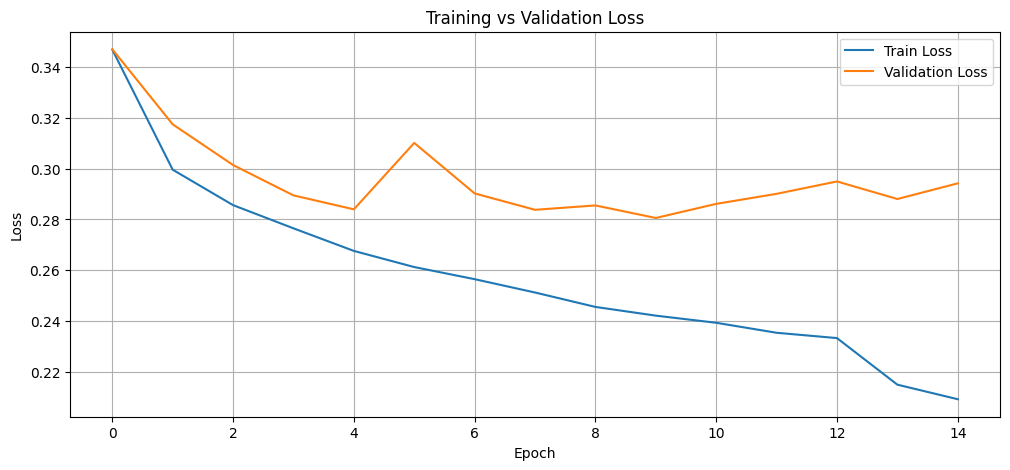

In [5]:
import torch.nn as nn
import torch.optim as optim
from utils import train, plot_losses

import os
os.makedirs("../outputs", exist_ok=True)

# Step 4: Define loss + optimizer
criterion = nn.BCEWithLogitsLoss()      # Since PTB‑XL is multi-label --> BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

train_losses, val_losses = train(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=50,
    patience=5,
    checkpoint_path="../outputs/best_ecg_model.pt",
    device=DEVICE,
)

plot_losses(train_losses, val_losses, save_path="../outputs/loss_curve.png")


## 4. Evaluation

In [6]:
from utils import (
    get_predictions,
    compute_auc_per_class,
    compute_macro_auc,
    plot_auc_bar,
    plot_prediction_vs_truth,
    plot_confusion_matrices,
    compute_all_metrics,
)

# Load best model
model.load_state_dict(torch.load("../outputs/best_ecg_model.pt", map_location=DEVICE))
model.eval()

all_preds, all_targets = get_predictions(model, test_dl, device=DEVICE)

# -------------------------
# FULL METRICS
# -------------------------
print("\n=== ECG MODEL RESULTS ===")

metrics = compute_all_metrics(all_targets, all_preds)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

C:\Users\inaki\AppData\Local\Temp\ipykernel_49312\3287662731.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../outputs/best_ecg_model


=== ECG MODEL RESULTS ===
Accuracy: 0.6128
F1: 0.7105
Precision (PPV): 0.7691
Sensitivity (Recall): 0.6715
Specificity: 0.9254
MCC: 0.6771
AUC: 0.9197


Per-class AUC: {'CD': 0.9109977351123916, 'HYP': 0.8976582707715602, 'MI': 0.9147429390997351, 'NORM': 0.9451671354278339, 'STTC': 0.9299527192443319}
Macro AUC: 0.9197


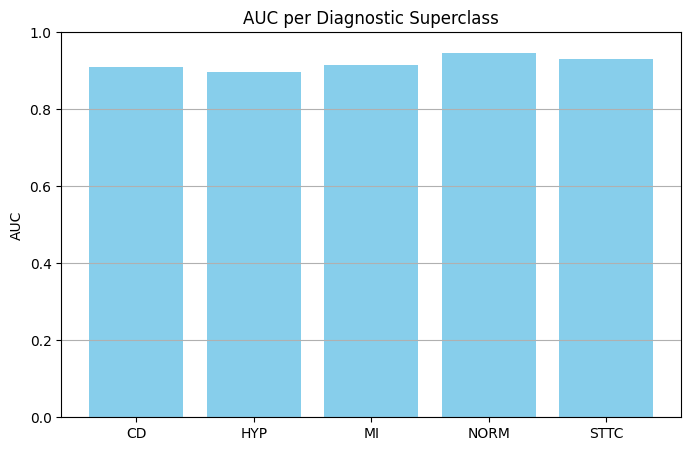

Macro AUC: 0.9197


In [7]:
# Per-class & macro AUC
auc_scores = compute_auc_per_class(all_targets, all_preds, classes)
macro_auc  = compute_macro_auc(auc_scores)

print("Per-class AUC:", auc_scores)
print(f"Macro AUC: {macro_auc:.4f}")

plot_auc_bar(auc_scores, save_path="../outputs/auc_bar.png")


Ground truth: [0. 0. 0. 1. 0.]
Predictions : [0.00630814 0.00151305 0.01137681 0.9856495  0.00180369]


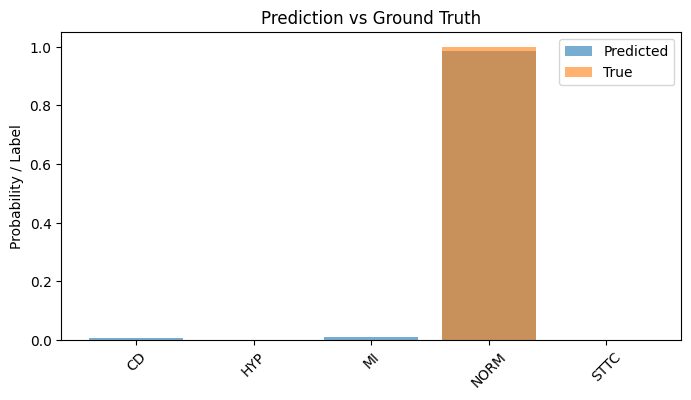

In [8]:
# Single-sample prediction vs truth
plot_prediction_vs_truth(
    all_preds, all_targets, classes,
    sample_idx=0,
    save_path="../outputs/pred_vs_truth.png",
)


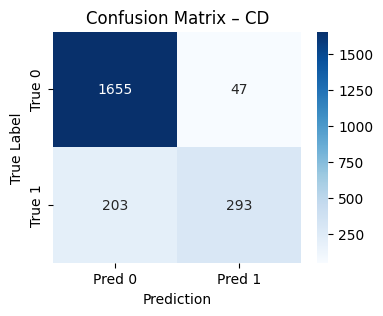

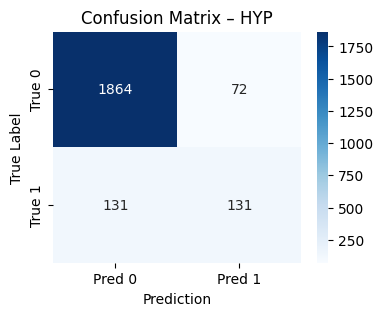

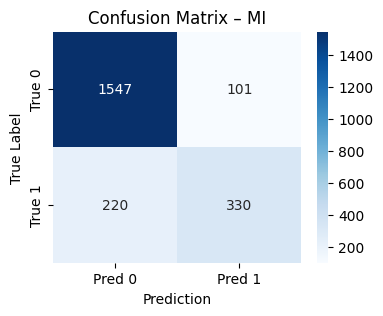

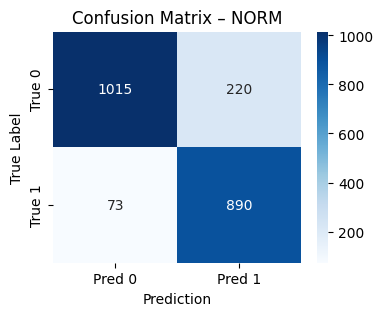

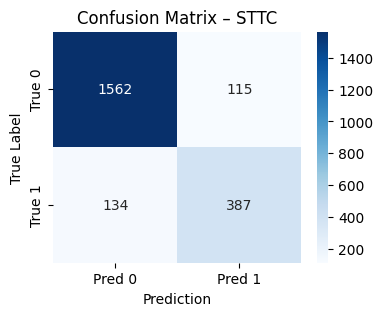

In [9]:
# Confusion matrices for all classes
plot_confusion_matrices(
    all_targets, all_preds, classes,
    threshold=0.5,
    save_dir="../outputs/confusion_matrices",
)
